# Assignment 1: Linear Classification and Regression

This assignment has **50 marks (6.5% of final grades)**.


**Deadline: October 9 at 11:59PM**


We will cover a variety of lectures and tutorials in this assignment including  Linear regression and classification.

Please note that similar codes between individuals will considered violation under the academic integrity policy, and the instructor holds the right to take any necessarry action.

## Note
* Use Google Colab to do this assignment.
* Don't change existing code or text.
* Add code and write text as instructed.
* Please pay attention to questions asked after writing code to analyze or conclude results (I usually put them in bullet points and bold them)

## Submission
* File > Download > (as .ipynb)
* Submit .ipynb file on the Learn.
* Please submit by the deadline

## Submission Notes
(Please write any notes or assumptions here that you think we should know during marking)

- The assignment explicitly mentioned we are using only first two class. Drop the third class initially before splitting the dataframe.

# Linear Classification and Regression



## Problem 1: Linear Classification and Regression on Iris flower dataset [50 marks]


The Iris flowers dataset is aviqlable on sklearn. The dataset consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters. Based on the combination of these four features, we can develop a linear classifier and regression to distinguish the species from each other. https://en.wikipedia.org/wiki/Iris_flower_data_set

We will only work with the first 2 flower classes (Setosa and Versicolour), and with just the length and width features of the sepal for the classification part.

For the Linear Regression, we will predict only the sepal length of the flowers







In [542]:
import matplotlib
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt
%matplotlib inline
#add other libraries if needed

Load the Dataset

In [543]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

# Adding some noise to make it more challenging
Creating a pandas dataframe from the observations.



In [544]:
I=np.random.normal(1.0, 0.2, size=(4, 150))# Adding noise - you can change that if needed
for i in range(4):
  iris.data[:,i]=np.random.normal(1.0,0.2)*iris.data[:,i]*I[i,:]

Features = pd.DataFrame(iris.data, columns=iris.feature_names)
Target = pd.DataFrame(iris.target, columns=['Target'])

df = Features
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,6.205374,3.081372,1.082125,0.241542
1,7.115746,2.613526,1.111156,0.258387
2,3.940769,2.922012,1.089835,0.265349
3,3.694138,2.222261,1.248002,0.250518
4,3.074235,2.818998,0.808397,0.157450
...,...,...,...,...
145,8.180494,2.595537,3.647832,2.607787
146,7.821519,2.052460,2.888844,2.374003
147,10.187963,2.548265,4.896046,1.219965
148,7.821701,2.525020,1.285464,3.277016


## Take 25% of data as the test data

In [545]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.25)
test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
81,6.311072,1.793824,3.195700,1.420488
9,4.673599,2.207582,1.058824,0.158765
117,6.448026,2.909618,5.998085,2.452773
63,6.741403,2.516104,2.723710,1.573122
4,3.074235,2.818998,0.808397,0.157450
147,10.187963,2.548265,4.896046,1.219965
120,7.338294,2.065267,4.741438,2.434730
69,4.569960,2.096008,3.640644,1.794210
22,4.426672,2.943271,0.631134,0.259391
105,8.615651,2.217277,5.552970,2.109094


# Q1: Plot the Iris dataset  [3 pts]

Plot the length and width features as a scatter plot for each of the 2 flower classes Setosa and Versicolour


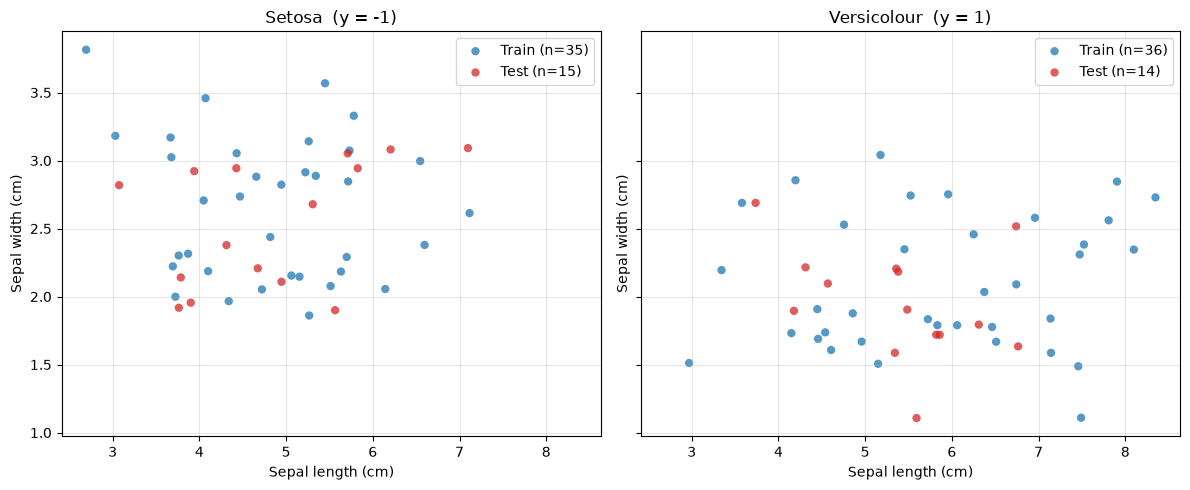

In [546]:
# Assert Dataset Size
assert df.shape == (150, 4)
assert Target.shape == (150, 1)

def preprocess(frame):
    '''
    Remove the Virginica class, then relabel Setosa as -1 and Versicolour as +1.
    '''
    idx = frame.index[frame.index.map(Target['Target']) != 2]
    return df.loc[idx, iris.feature_names], \
      Target['Target'].loc[idx].map({0: -1, 1: 1})

X_train, y_train = preprocess(train)
X_test,  y_test  = preprocess(test)

# Plot Histogram
xcol, ycol = 'sepal length (cm)', 'sepal width (cm)'
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, cls, name in [(axes[0], -1, 'Setosa'), (axes[1], 1, 'Versicolour')]:
  for X, y, split, color, marker in [
    (X_train, y_train, 'Train', 'tab:blue', 'o'),
    (X_test,  y_test,  'Test',  'tab:red',  'o'),
  ]:
    pts = X[y == cls]                      # boolean mask, aligned by index
    ax.scatter(pts[xcol], pts[ycol], color=color, marker=marker,
                alpha=0.75, edgecolor='none', label=f'{split} (n={len(pts)})')
  ax.set_title(f'{name}  (y = {cls})')
  ax.set_xlabel('Sepal length (cm)')
  ax.set_ylabel('Sepal width (cm)')
  ax.grid(True, alpha=0.3)
  ax.legend()

plt.tight_layout()
plt.show()

# Q2: What can you conclude about the decision boundary choice? [2 pts]



*   ***Answer to Q2:***



The two classes overlap, so a linear boundary is a reasonable choice even though no line separates them perfectly. The decision function is f(x) = w₁x₁ + w₂x₂. A point is classified by the sign of f(x): f(x) < 0 gives Setosa (y = −1) and f(x) > 0 gives Versicolour (y = +1). A point with f(x) = 0 lies exactly on the boundary and cannot be assigned a class.

# Q3: Linear Classification using gradient descent [25 pts]

Using the gradient descent algorithm we did in class in lecture 4 solve the Iris dataset problem. Make sure you comment your code and write down any explanation necessary for partial marks


**Write down your assumptions or steps you want us to look at here:**

* **Goal:** implement a linear binary classifier trained by gradient descent.
* **Input:** the train and test splits, each with its ±1 label (Setosa = −1, Versicolour = +1).
* **Output:** the model weights w₁ and w₂, and the accuracy (correct predictions / total samples).
* **Setup:** initialise w₁ and w₂ as the model weights, α as the learning rate, and the number of epochs to run.
* **In each epoch:**
  * Forward pass: compute the score f(x) = w₁x₁ + w₂x₂ for every training point.
  * gradient descent: take the hinge loss max{1 − y·f(x), 0} at each point
    * if the hinge loss > 0 (misclassified or inside the margin)
      * the point contributes gradient −x·y
    * otherwise
      * it contributes 0
  * Update the weights: w ← w − α∇L
  * Compute and print the accuracy.


Start with training predictions to create your predictor



In [547]:
#Write your training code here and comment it
# Model Parameter
w1 = 0.5
w2 = 0
alpha = 0.01
epochs = 1000

# Training Set Size
n = float(len(y_train))

# sepal length and width
X1 = X_train['sepal length (cm)'].to_numpy()
X2 = X_train['sepal width (cm)'].to_numpy()
Y  = y_train.to_numpy()

def accuracy(y_true, y_pred):
  correct = np.sum(y_true == y_pred)
  return correct / len(y_true)

def forward(w1, w2):
  '''
    Compute the score
  '''
  return w1*X1 + w2*X2

def hinge_loss(scores):
  return np.maximum(0, 1 - scores*Y)

def gradient_descent(scores):
  grads_w1 = []
  grads_w2 = []
  for x1, x2, y, m in zip(X1, X2, Y, hinge_loss(scores)):
    if m > 0:
      grads_w1.append(-x1*y)
      grads_w2.append(-x2*y)
    else:
      grads_w1.append(0)
      grads_w2.append(0)
  return [np.mean(grads_w1), np.mean(grads_w2)]

def update(w, dw):
  return w - alpha*dw


for i in range(epochs):
  scores = forward(w1, w2)
  d_w1, d_w2 = gradient_descent(scores)
  w1, w2 = update(w1, d_w1), update(w2, d_w2)
  acc = accuracy(y_train, np.sign(scores))
  print(f'epoch {i}: line: {w1:.3f}*x1 + {w2:.3f}*x2, accuracy = {acc:.3f}')


epoch 0: line: 0.476*x1 + -0.013*x2, accuracy = 0.507
epoch 1: line: 0.452*x1 + -0.026*x2, accuracy = 0.507
epoch 2: line: 0.428*x1 + -0.039*x2, accuracy = 0.507
epoch 3: line: 0.404*x1 + -0.052*x2, accuracy = 0.507
epoch 4: line: 0.380*x1 + -0.065*x2, accuracy = 0.507
epoch 5: line: 0.356*x1 + -0.078*x2, accuracy = 0.507
epoch 6: line: 0.333*x1 + -0.091*x2, accuracy = 0.507
epoch 7: line: 0.310*x1 + -0.104*x2, accuracy = 0.507
epoch 8: line: 0.288*x1 + -0.116*x2, accuracy = 0.507
epoch 9: line: 0.266*x1 + -0.127*x2, accuracy = 0.507
epoch 10: line: 0.248*x1 + -0.137*x2, accuracy = 0.507
epoch 11: line: 0.232*x1 + -0.146*x2, accuracy = 0.507
epoch 12: line: 0.219*x1 + -0.154*x2, accuracy = 0.507
epoch 13: line: 0.208*x1 + -0.162*x2, accuracy = 0.507
epoch 14: line: 0.200*x1 + -0.168*x2, accuracy = 0.521
epoch 15: line: 0.194*x1 + -0.174*x2, accuracy = 0.521
epoch 16: line: 0.189*x1 + -0.179*x2, accuracy = 0.521
epoch 17: line: 0.187*x1 + -0.184*x2, accuracy = 0.521
epoch 18: line: 0.18

Now using the test set test the accuracy of your predictor

Linear Classifier: 0.617*x1 + -1.447*x2
test  accuracy: 0.7931034482758621


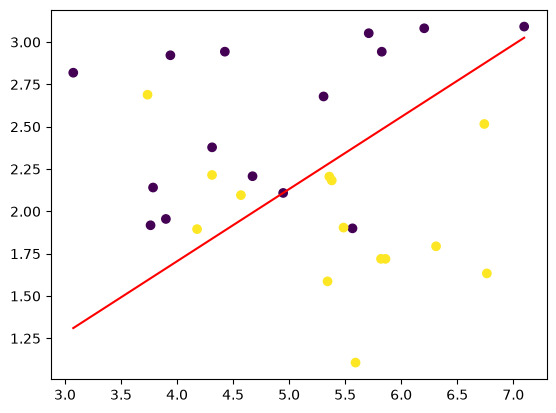

In [548]:
#Write your testing code here and comment it
print(f'Linear Classifier: {w1:.3f}*x1 + {w2:.3f}*x2')

# Prepare Train Set
X_1 = X_test['sepal length (cm)'].to_numpy()
X_2 = X_test['sepal width (cm)'].to_numpy()
Y   = y_test.to_numpy()

# Compute Score and the model prediction
score = w1*X_1 + w2*X_2
Y_pred = np.sign(score)

# Print the final Accuracy
print('test  accuracy:', accuracy(y_test, Y_pred))

# Plot
plt.scatter(X_1, X_2, c=Y)

x_line = np.linspace(min(X_1), max(X_1), 100)
plt.plot(x_line, -(w1/w2) * x_line, color='red')


plt.show()

# Q4: Using sklearn for Classification [10 pts]

Using sklearn built in logistic regression model, solve the Iris classication problem. [5 pts]

decision boundary: 0.605*x1 + -1.673*x2 + 0.733 = 0
test  accuracy: 0.8275862068965517


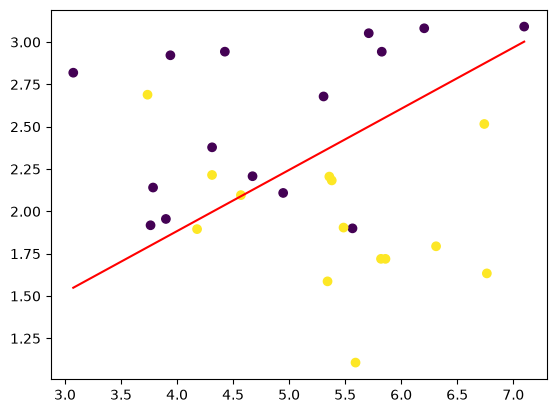

In [549]:
#Write your code here and comment it
from sklearn.linear_model import LogisticRegression

# Import Linear Regression model
model = LogisticRegression()
model.fit(X_train[['sepal length (cm)', 'sepal width (cm)']], y_train)

# Get Model Parameter
lr_w1, lr_w2 = model.coef_[0]
lr_b = model.intercept_[0]

# Use Model to Predict Test Set
y_pred = model.predict(X_test[['sepal length (cm)', 'sepal width (cm)']])

# Print result and plot
print(f'decision boundary: {lr_w1:.3f}*x1 + {lr_w2:.3f}*x2 + {lr_b:.3f} = 0')
print('test  accuracy:', accuracy(y_test, y_pred))

plt.scatter(X_1, X_2, c=Y)

x_line = np.linspace(min(X_1), max(X_1), 100)
plt.plot(x_line, -(lr_w1*x_line + lr_b)/lr_w2, color='red')

plt.show()



*   Compare your results against your Classifier from Q3. Conclude as why one may perform better than the other. [5 pts]

**Answer:**

sklearn's logistic regression have an extra biased term, giving its boundary an extra degree of freedom. In most cases the accuracy are similar since the data can be separated by a line through the origin.

# Q5: Using sklearn for Linear Regression [10 pts]

---



Using sklearn built in linear regression model, predict the sepal length of the iris flowers. [10 pts]


From your code in part 1:

*   Load the sepal length for your prediction and split the data into training testing again
*   Use the sepal width, petal width, petal length, and the species as your input
*   Train your predictor to approximates the sepal length using the built in linear regression model from sklearn
*   Evaluate your model using the mean squared error (use the built in function in sklearn)
*   Test your predictor using the test set and report both predictions (sepal length) and the mean squared error on them









In [550]:
#Write your code here and comment it
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Input Column Naming
features = ['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Prepare Input with Class Label and Output
X_reg_train = df.loc[train.index, features].copy()
X_reg_test  = df.loc[test.index,  features].copy()
X_reg_train['Target'] = Target['Target'].loc[train.index]
X_reg_test['Target']  = Target['Target'].loc[test.index]
y_reg_train = df.loc[train.index, 'sepal length (cm)']
y_reg_test  = df.loc[test.index,  'sepal length (cm)']

# Train the linear regression model
model = LinearRegression()
model.fit(X_reg_train, y_reg_train)

# Print the model
terms = ' + '.join(f'{c:.3f}*{name}' for c, name in zip(model.coef_, X_reg_train.columns))
print(f'sepal length = {terms} + {model.intercept_:.3f}\n')


# Predict result and Compute MSE as metric 
test_pred = model.predict(X_reg_test)
print('test  MSE:', mean_squared_error(y_reg_test, test_pred))

# Print all results
results = pd.DataFrame({'actual sepal length': y_reg_test,
                        'predicted sepal length': test_pred})
results['error'] = results['predicted sepal length'] - results['actual sepal length']
print('\nTest set predictions:')
print(results.round(3).to_string())

sepal length = 0.175*sepal width (cm) + 0.296*petal length (cm) + 0.161*petal width (cm) + 0.467*Target + 3.938

test  MSE: 1.4954581509003748

Test set predictions:
     actual sepal length  predicted sepal length  error
81                 6.311                   5.892 -0.419
9                  4.674                   4.662 -0.012
117                6.448                   7.550  1.102
63                 6.741                   5.903 -0.838
4                  3.074                   4.694  1.620
147               10.188                   6.962 -3.226
120                7.338                   7.028 -0.311
69                 4.570                   6.137  1.567
22                 4.427                   4.680  0.253
105                8.616                   7.242 -1.374
148                7.822                   6.222 -1.600
52                 3.737                   6.860  3.123
55                 5.593                   5.629  0.036
93                 4.179                   5.716  